# LOS/NLOS UWB Signal Classification for Indoor Precise Positioning

## Data Analytics 3D Pipeline: Data Preparation, Data Mining, Data Visualization

## 1. Introduction

Ultra-wideband (UWB) positioning can achieve high ranging precision, but indoor performance degrades under multipath propagation and non-line-of-sight (NLOS) obstruction. When the first arriving path is blocked or when reflected paths dominate the channel impulse response (CIR), range estimates become positively biased and localization accuracy deteriorates. This notebook implements a complete analytics workflow for identifying LOS/NLOS conditions and estimating path distances from Decawave DWM1000 CIR measurements.

The dataset contains 42,000 labeled measurements collected across seven indoor environments, with 21,000 LOS and 21,000 NLOS samples. Each measurement combines scalar radio diagnostics such as `FP_IDX`, `RXPACC`, and `CIR_PWR` with a 1016-sample CIR waveform at 1 ns resolution. To align with the CSC3105 mini-project requirements, the notebook explicitly follows the 3D methodology: **Data Preparation** (cleaning, normalization, path extraction, feature construction), **Data Mining** (classification, regression, clustering, augmentation), and **Data Visualization** (saved figures displayed inline for interpretation).

In [1]:
%matplotlib inline

import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import HTML, Image, display

from sklearn.feature_selection import RFECV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc as sk_auc, confusion_matrix,
)

from src.data_loader import load_dataset
from src.preprocessing import preprocess, scale_and_split, SCALAR_FEATURES
from src.peak_detection import extract_two_paths
from src.feature_engineering import build_features
from src.classification import train_classifiers
from src.regression import train_regressors
from src.clustering import (
    run_kmeans_analysis,
    run_elbow_silhouette_analysis,
    run_dbscan_analysis,
)
from src.ensemble import build_ensemble
from src.synthetic_data import apply_smote, generate_augmented_cir
import src.visualization as viz

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['figure.dpi'] = 110

pd.set_option('display.max_columns', 120)
pd.set_option('display.precision', 4)

display(HTML('''
<style>
.jp-OutputArea-output img {
    max-width: 100% !important;
    height: auto !important;
}
</style>
'''))

def show_plot(path, width=900):
    display(Image(filename=path, width=width))

print('Notebook setup complete.')
print(f'Plot directory: {viz.PLOT_DIR}')

Notebook setup complete.
Plot directory: plots/


## 2. Data Loading

The raw dataset is distributed across seven CSV files, one for each indoor environment (Office 1, Office 2, Small Apartment, Small Workshop, Kitchen with Living Room, Bedroom, Boiler Room). Each row contains 14 scalar Decawave diagnostics, a 1016-sample CIR waveform, and the binary `NLOS` label. The loader adds an `ENV_ID` column (0--6) to track each sample's origin environment. Before any transformation, we consolidate these files into one DataFrame and verify the class balance, dimensionality, and environment coverage.

In [2]:
start_time = time.time()

df_raw = load_dataset()

# Preserve environment IDs aligned to rows that survive preprocessing.
# preprocess() removes degenerate samples (RANGE=0 or CIR_PWR=0), so we
# apply the same mask here to keep env_ids in sync with the cleaned data.
_degenerate = ((df_raw['RANGE'] == 0) | (df_raw['CIR_PWR'] == 0) | (df_raw['RXPACC'] == 0))
env_ids = df_raw.loc[~_degenerate, 'ENV_ID'].values.copy()

print(f'Raw dataset shape: {df_raw.shape}')
print(f'Number of environments: {df_raw["ENV_ID"].nunique()}')
print(df_raw['NLOS'].value_counts().rename(index={0: 'LOS', 1: 'NLOS'}))

display(df_raw.head())

Loaded dataset: 42000 samples, 1032 columns
  LOS: 21000, NLOS: 21000
  Environments: 7 (ENV_ID 0-6)
Raw dataset shape: (42000, 1032)
Number of environments: 7
NLOS
LOS     21000
NLOS    21000
Name: count, dtype: int64


,NLOS,RANGE,FP_IDX,FP_AMP1,FP_AMP2,FP_AMP3,STDEV_NOISE,CIR_PWR,MAX_NOISE,RXPACC,CH,FRAME_LEN,PREAM_LEN,BITRATE,PRFR,CIR0,CIR1,CIR2,CIR3,CIR4,CIR5,CIR6,CIR7,CIR8,CIR9,CIR10,CIR11,CIR12,CIR13,CIR14,CIR15,CIR16,CIR17,CIR18,CIR19,CIR20,CIR21,CIR22,CIR23,CIR24,CIR25,CIR26,CIR27,CIR28,CIR29,CIR30,CIR31,CIR32,CIR33,CIR34,CIR35,CIR36,CIR37,CIR38,CIR39,CIR40,CIR41,CIR42,CIR43,CIR44,...,CIR957,CIR958,CIR959,CIR960,CIR961,CIR962,CIR963,CIR964,CIR965,CIR966,CIR967,CIR968,CIR969,CIR970,CIR971,CIR972,CIR973,CIR974,CIR975,CIR976,CIR977,CIR978,CIR979,CIR980,CIR981,CIR982,CIR983,CIR984,CIR985,CIR986,CIR987,CIR988,CIR989,CIR990,CIR991,CIR992,CIR993,CIR994,CIR995,CIR996,CIR997,CIR998,CIR999,CIR1000,CIR1001,CIR1002,CIR1003,CIR1004,CIR1005,CIR1006,CIR1007,CIR1008,CIR1009,CIR1010,CIR1011,CIR1012,CIR1013,CIR1014,CIR1015,ENV_ID
0,0.0,3.90,745.0,18712.0,10250.0,11576.0,64.0,11855.0,967.0,611.0,2.0,39.0,1024.0,110.0,64.0,129.0,312.0,331.0,141.0,160.0,488.0,195.0,144.0,119.0,193.0,158.0,192.0,120.0,35.0,295.0,111.0,292.0,170.0,84.0,107.0,293.0,200.0,333.0,450.0,241.0,162.0,97.0,449.0,146.0,66.0,165.0,455.0,190.0,142.0,218.0,280.0,219.0,238.0,265.0,207.0,123.0,164.0,195.0,322.0,222.0,...,130.0,256.0,199.0,200.0,183.0,278.0,432.0,211.0,263.0,105.0,402.0,320.0,133.0,170.0,207.0,280.0,399.0,457.0,162.0,329.0,162.0,325.0,121.0,110.0,291.0,301.0,259.0,251.0,156.0,200.0,287.0,177.0,402.0,216.0,242.0,249.0,420.0,306.0,86.0,278.0,487.0,445.0,169.0,243.0,425.0,235.0,164.0,297.0,114.0,279.0,458.0,183.0,158.0,198.0,87.0,296.0,505.0,307.0,0.0,0
1,0.0,0.66,749.0,11239.0,6313.0,4712.0,64.0,18968.0,1133.0,447.0,2.0,27.0,1024.0,110.0,64.0,117.0,163.0,199.0,136.0,142.0,182.0,358.0,123.0,280.0,311.0,236.0,166.0,240.0,286.0,117.0,242.0,250.0,318.0,204.0,259.0,82.0,207.0,145.0,255.0,201.0,179.0,255.0,50.0,201.0,184.0,178.0,279.0,99.0,289.0,190.0,93.0,289.0,329.0,164.0,132.0,145.0,195.0,131.0,76.0,85.0,...,202.0,285.0,151.0,254.0,200.0,122.0,81.0,223.0,75.0,174.0,263.0,249.0,148.0,187.0,229.0,172.0,107.0,65.0,338.0,147.0,51.0,283.0,255.0,322.0,311.0,159.0,330.0,194.0,57.0,148.0,123.0,149.0,62.0,60.0,379.0,196.0,140.0,90.0,177.0,257.0,277.0,87.0,473.0,277.0,107.0,104.0,161.0,168.0,196.0,144.0,334.0,290.0,228.0,187.0,213.0,202.0,89.0,103.0,0.0,0
2,1.0,7.86,746.0,4355.0,5240.0,3478.0,60.0,14699.0,894.0,723.0,2.0,27.0,1024.0,110.0,64.0,433.0,240.0,233.0,81.0,143.0,506.0,119.0,272.0,248.0,233.0,233.0,95.0,255.0,189.0,142.0,274.0,131.0,253.0,115.0,102.0,50.0,417.0,239.0,40.0,218.0,161.0,235.0,165.0,153.0,262.0,146.0,240.0,258.0,101.0,228.0,204.0,147.0,130.0,201.0,285.0,209.0,168.0,115.0,246.0,274.0,...,310.0,95.0,92.0,222.0,209.0,373.0,303.0,69.0,196.0,180.0,127.0,129.0,103.0,302.0,264.0,262.0,266.0,199.0,202.0,192.0,280.0,31.0,200.0,234.0,122.0,445.0,89.0,329.0,288.0,139.0,160.0,217.0,550.0,215.0,257.0,217.0,279.0,30.0,314.0,234.0,138.0,196.0,264.0,251.0,83.0,154.0,82.0,324.0,208.0,32.0,373.0,224.0,174.0,124.0,329.0,207.0,96.0,218.0,0.0,0
3,1.0,3.48,750.0,8502.0,8416.0,5890.0,76.0,8748.0,1127.0,1024.0,2.0,39.0,1024.0,110.0,64.0,466.0,247.0,407.0,225.0,279.0,69.0,393.0,436.0,289.0,169.0,308.0,233.0,177.0,398.0,500.0,71.0,291.0,194.0,408.0,282.0,182.0,293.0,194.0,352.0,467.0,194.0,258.0,164.0,442.0,126.0,359.0,517.0,199.0,211.0,214.0,127.0,151.0,201.0,295.0,94.0,201.0,248.0,246.0,53.0,418.0,...,282.0,138.0,334.0,60.0,152.0,484.0,370.0,347.0,136.0,195.0,233.0,322.0,473.0,487.0,380.0,266.0,299.0,141.0,195.0,319.0,146.0,246.0,218.0,163.0,332.0,155.0,269.0,291.0,395.0,189.0,81.0,121.0,195.0,261.0,534.0,193.0,34.0,214.0,451.0,421.0,231.0,263.0,248.0,381.0,224.0,372.0,483.0,125.0,210.0,252.0,173.0,198.0,160.0,434.0,397.0,290.0,155.0,342.0,256.0,0
4,0.0,1.19,746.0,17845.0,18095.0,12058.0,68.0,11380.0,1744.0,276.0,2.0,27.0,1024.0,110.0,64.0,259.0,239.0,57.0,19.0,88.0,219.0,400.0,151.0,98.0,415.0,144.0,130.0,106.0,216.0,239.0,112.0,121.0,466.0,74.0,315.0,255.0,281.0,392.0,132.0,129.0,216.0,151.0,266.0,295.0,212.0,391.0,251.0,376.0,133.0,242.0,143.0,54.0,241.0,214.0,250.0,258.0,105.0,263.0,3

## 3. Data Preparation

### 3.1 Data Cleaning and Preprocessing

The preprocessing stage checks for missing values, removes degenerate hardware-error samples where `RANGE = 0` or `CIR_PWR = 0`, drops constant-valued columns (`CH`, `BITRATE`, `PRFR`), and normalizes every CIR amplitude sample by dividing by `RXPACC`. This normalization is physically justified because the raw CIR is accumulated over a varying number of received preamble symbols; dividing by `RXPACC` yields a per-pulse representation that is comparable across measurements. Interquartile-range outliers are intentionally retained because large values of `RANGE`, `FP_IDX`, or noise statistics typically correspond to genuine NLOS behaviour rather than spurious measurement error.

In [3]:
df = preprocess(df_raw)
print(f'Preprocessed dataset shape: {df.shape}')
print(f'Samples removed during cleaning: {len(df_raw) - len(df)}')

Missing values check: 0 missing (dataset is clean)
Removed 4 degenerate samples (RANGE=0 or CIR_PWR=0)
Dropped constant columns: ['CH', 'BITRATE', 'PRFR', 'ENV_ID']
  Note: PREAM_LEN is near-constant (96.3% = 1024.0)
Normalized 1016 CIR columns by RXPACC
Preprocessed dataset shape: (41996, 1028)
Samples removed during cleaning: 4


### 3.2 Feature Scaling and Train/Test Split

The retained scalar features span different numerical ranges, so standardization is applied for scale-sensitive algorithms (Logistic Regression, SVM, neural networks) and distance-based clustering. A stratified 80/20 split is performed first, and the `StandardScaler` is fitted exclusively on the training subset to prevent data leakage. Each scalar feature is then transformed as $z = (x - \mu_{\text{train}}) / \sigma_{\text{train}}$, ensuring that the held-out test set is never used to inform the scaling parameters.

In [4]:
df_scaled, train_idx, test_idx, scaler = scale_and_split(df)
print(f'Scaled dataset shape: {df_scaled.shape}')
print(f'Train indices: {len(train_idx)}, Test indices: {len(test_idx)}')

Train/test split: 33596 / 8400 (stratified)
StandardScaler fit on training set only (33596 samples)
Scaled dataset shape: (41996, 1028)
Train indices: 33596, Test indices: 8400


### 3.3 Two Dominant Path Extraction

For each normalized CIR waveform, the algorithm refines the first dominant path around the hardware-reported `FP_IDX` by searching for the local maximum within a narrow window. The second dominant path is then identified as the next prominent peak outside a temporal exclusion zone around Path 1, using adaptive prominence thresholds and light smoothing to suppress noise peaks. This design reflects UWB propagation physics: the earliest detected path is the most likely direct arrival, whereas later prominent peaks usually represent reflections or obstructed paths.

In [5]:
path1_idx, path1_amp, path2_idx, path2_amp = extract_two_paths(df)
print('Peak arrays prepared:')
print(f'  Path 1 detections: {len(path1_idx)}')
print(f'  Path 2 detections: {(path2_amp > 0).sum()} / {len(path2_amp)}')

Peak detection: path2 found in 40862/41996 samples (97.3%)
Peak arrays prepared:
  Path 1 detections: 41996
  Path 2 detections: 40862 / 41996


### 3.4 Feature Engineering

The feature set combines local waveform descriptors around each detected path, full-CIR statistical moments, shared scalar diagnostics, and physically motivated derived variables. Specifically, each path row contains:

- **13 per-path features** (prefixed `p_`): 8 waveform shape features (path index, amplitude, rise time, decay time, local kurtosis, energy ratio, peak-to-noise ratio, amplitude ratio) and 5 CIR-wide statistics (RMS delay spread, mean excess delay, full-CIR kurtosis, max-to-mean ratio, tail energy ratio).
- **9 shared scalar features**: `FP_AMP1`, `FP_AMP2`, `FP_AMP3`, `STDEV_NOISE`, `CIR_PWR`, `MAX_NOISE`, `RXPACC`, `FRAME_LEN`, `PREAM_LEN`.
- **3 derived shared features**: `path_delay_separation`, `path1_to_fp_offset`, `relative_power`.

This gives **25 features per row**. Each original sample is expanded into two path-specific rows, approximately doubling the dataset. The path labelling rule follows propagation physics: if the original sample is LOS, Path 1 is LOS and Path 2 is NLOS; if the original sample is NLOS, both paths are labelled NLOS. Range targets for distance estimation are also assigned at this stage.

In [6]:
features_df, labels_cls, labels_range, path_ids = build_features(
    df, path1_idx, path1_amp, path2_idx, path2_amp,
)

# Map original train/test indices to expanded (two-path) indices
n_orig = len(df)
exp_train_idx = np.concatenate([train_idx, train_idx + n_orig])
exp_test_idx = np.concatenate([test_idx, test_idx + n_orig])

# Expand environment IDs to match two-path dataset
exp_env_ids = np.concatenate([env_ids, env_ids])
env_ids_test = exp_env_ids[exp_test_idx]

# Prepare ML classification data (expanded two-path dataset)
X_train_cls = features_df.iloc[exp_train_idx].values
y_train_cls = labels_cls[exp_train_idx]
X_test_cls = features_df.iloc[exp_test_idx].values
y_test_cls = labels_cls[exp_test_idx]

feature_names = list(features_df.columns)

print(f"ML pipeline: {X_train_cls.shape[0]} train / {X_test_cls.shape[0]} test, {X_train_cls.shape[1]} features")
print(f'Expanded feature table: {features_df.shape}')
print(f'Expanded labels: LOS={(labels_cls == 0).sum()}, NLOS={(labels_cls == 1).sum()}')

display(features_df.head())

  1134 samples had no second path detected
Feature engineering: 83992 rows (LOS=20999, NLOS=62993)
ML pipeline: 67192 train / 16800 test, 25 features
Expanded feature table: (83992, 25)
Expanded labels: LOS=20999, NLOS=62993


,p_path_idx,p_path_amp,p_rise_time,p_decay_time,p_kurtosis_local,p_energy_ratio,p_peak_to_noise,p_amplitude_ratio,p_rms_delay_spread,p_mean_excess_delay,p_kurtosis_full,p_max_to_mean,p_tail_energy_ratio,FP_AMP1,FP_AMP2,FP_AMP3,STDEV_NOISE,CIR_PWR,MAX_NOISE,RXPACC,FRAME_LEN,PREAM_LEN,path_delay_separation,path1_to_fp_offset,relative_power
0,748.0,37.7692,5.0,12.0,2.9306,0.9172,0.5901,5.1112,72.1223,742.5707,144.9586,58.3895,0.7560,18712.0,10250.0,11576.0,64.0,11855.0,967.0,611.0,39.0,1024.0,17,3.0,1.5784
1,757.0,40.4004,9.0,13.0,-1.2316,0.9462,0.6313,2.9260,50.4857,753.1356,77.0344,40.6679,0.4656,11239.0,6313.0,4712.0,64.0,18968.0,1133.0,447.0,27.0,1024.0,18,8.0,0.5925
2,754.0,23.2490,8.0,11.0,-0.8466,0.7810,0.3875,2.3711,66.4629,756.0161,58.3835,33.3853,0.8256,4355.0,5240.0,3478.0,60.0,14699.0,894.0,723.0,27.0,1024.0,23,8.0,0.2963
3,756.0,15.3730,7.0,5.0,0.6144,0.9152,0.2023,5.8024,101.3637,740.0201,105.6532,38.1112,0.6563,8502.0,8416.0,5890.0,76.0,8748.0,1127.0,1024.0,39.0,1024.0,21,6.0,0.9719
4,750.0,70.9529,6.0,1.0,0.8039,0.9502,1.0434,30.5031,71.4741,741.7912,151.4561,53.8946,0.4465,17845.0,18095.0,12058.0,68.0,11380.0,1744.0,276.0,27.0,1024.0,139,4.0,1.5681


## 4. Data Visualization: Preparation Stage

Visualization during the preparation stage validates assumptions before modelling. The plots below reveal how class balance changes after two-path expansion, how scalar features differ between LOS and NLOS conditions, how strongly variables co-vary, and whether the extracted peaks align with the expected CIR structure. Because the plotting utilities save and close each figure immediately, the notebook redisplays the saved PNGs inline to preserve readability while still producing report-ready files.

  Saved: plots/01_class_distribution.png


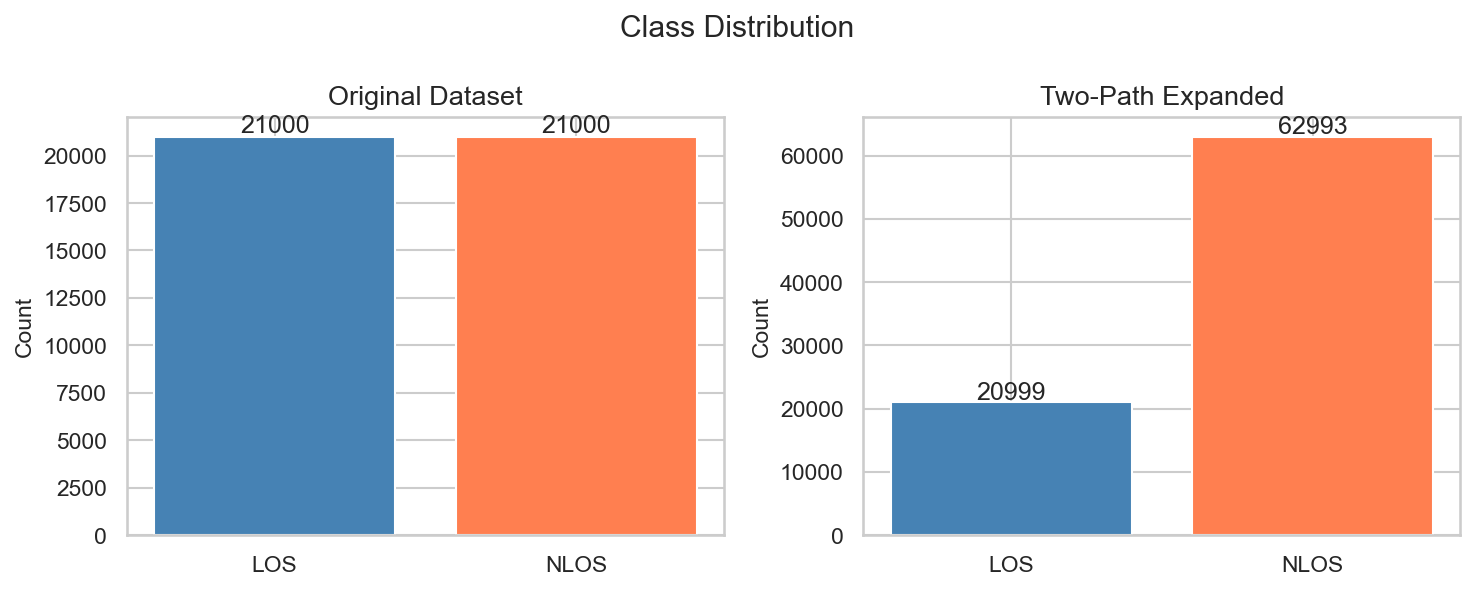

In [7]:
viz.plot_class_distribution(df_raw['NLOS'].values, labels_cls)
show_plot('plots/01_class_distribution.png', width=850)

  Saved: plots/02_feature_distributions.png


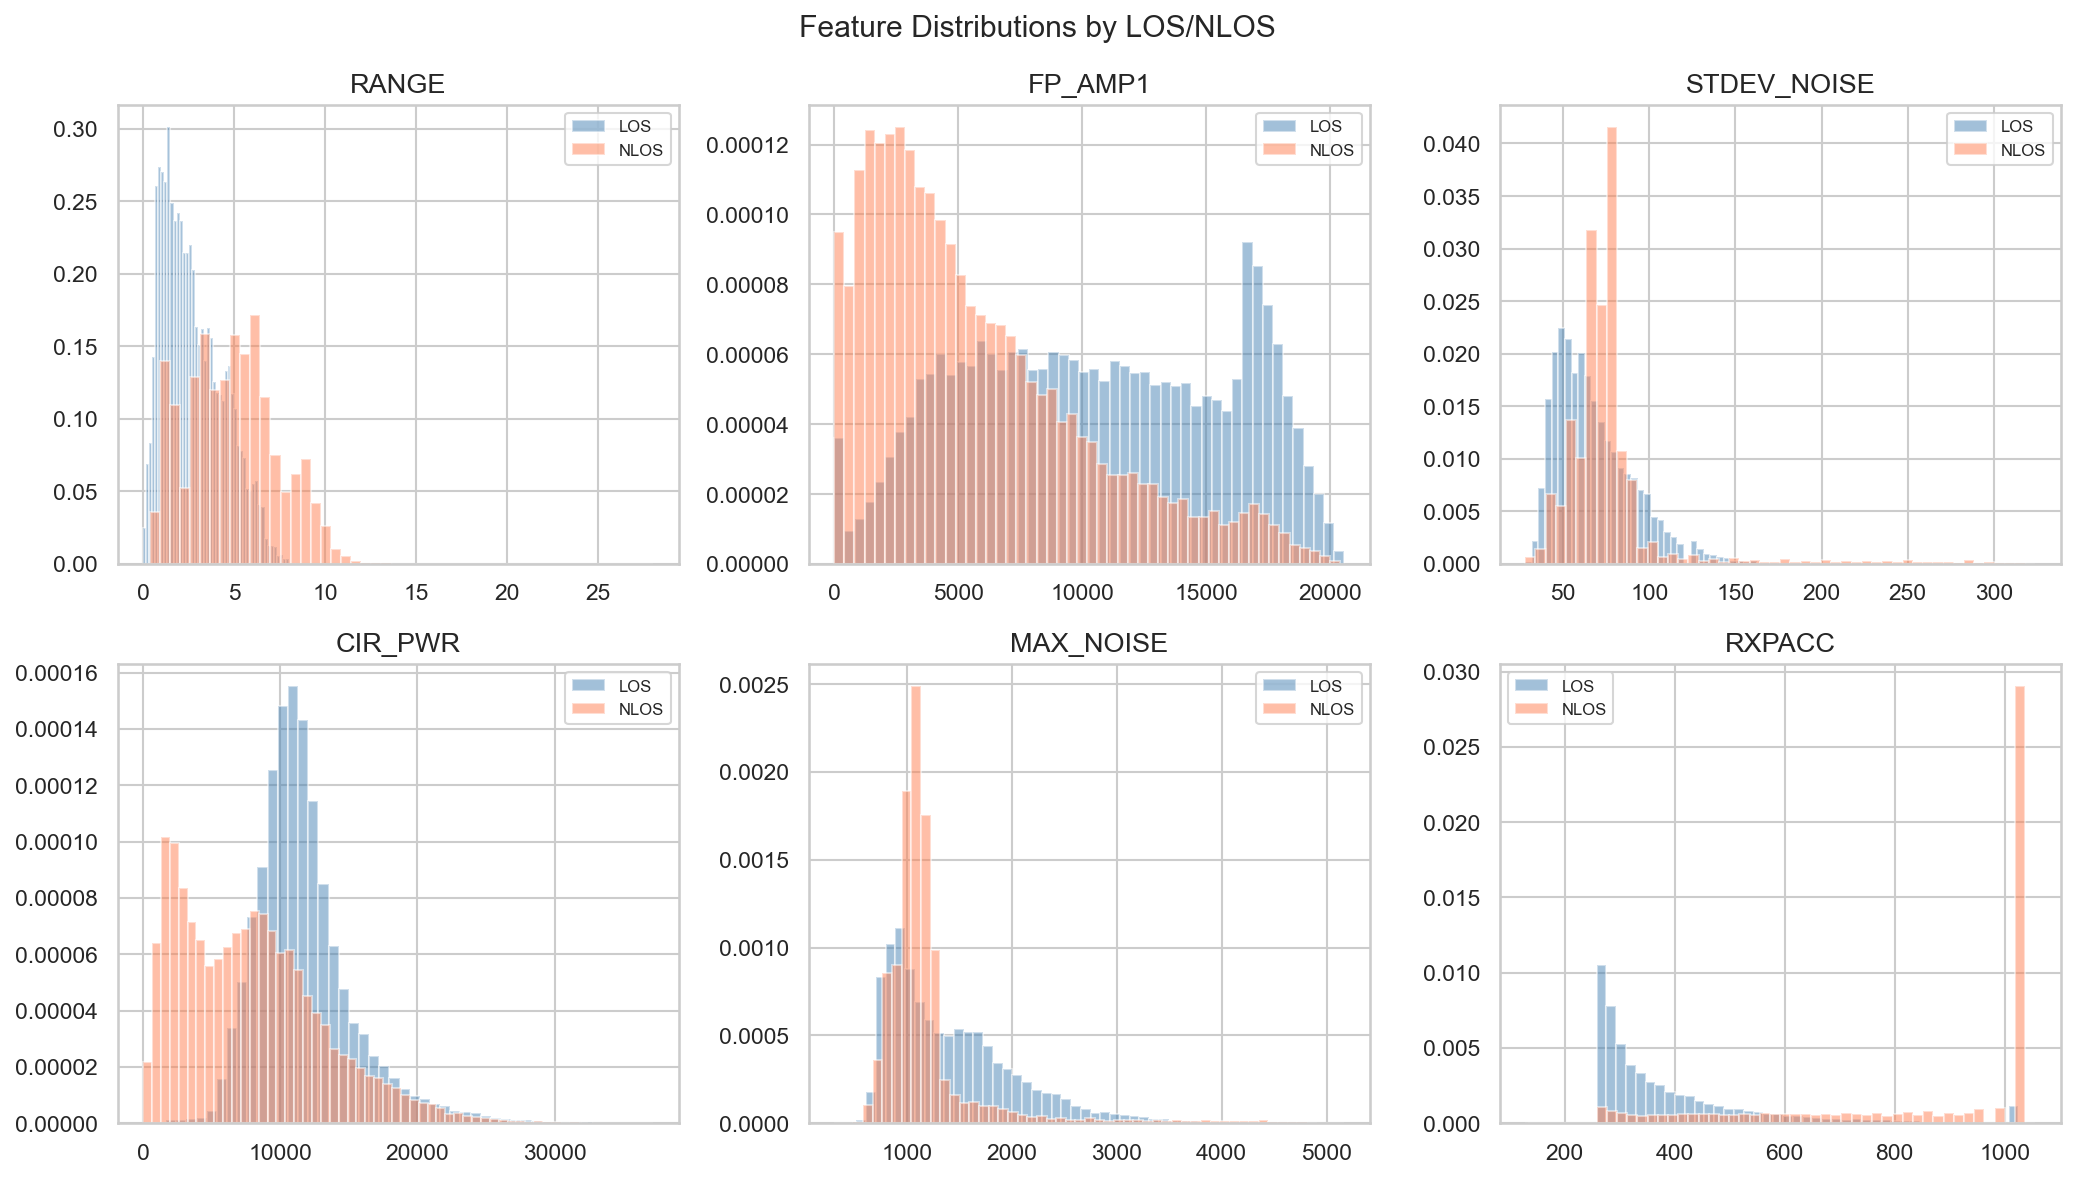

In [8]:
viz.plot_feature_distributions(df_raw)
show_plot('plots/02_feature_distributions.png', width=1000)

  Saved: plots/03_correlation_heatmap.png


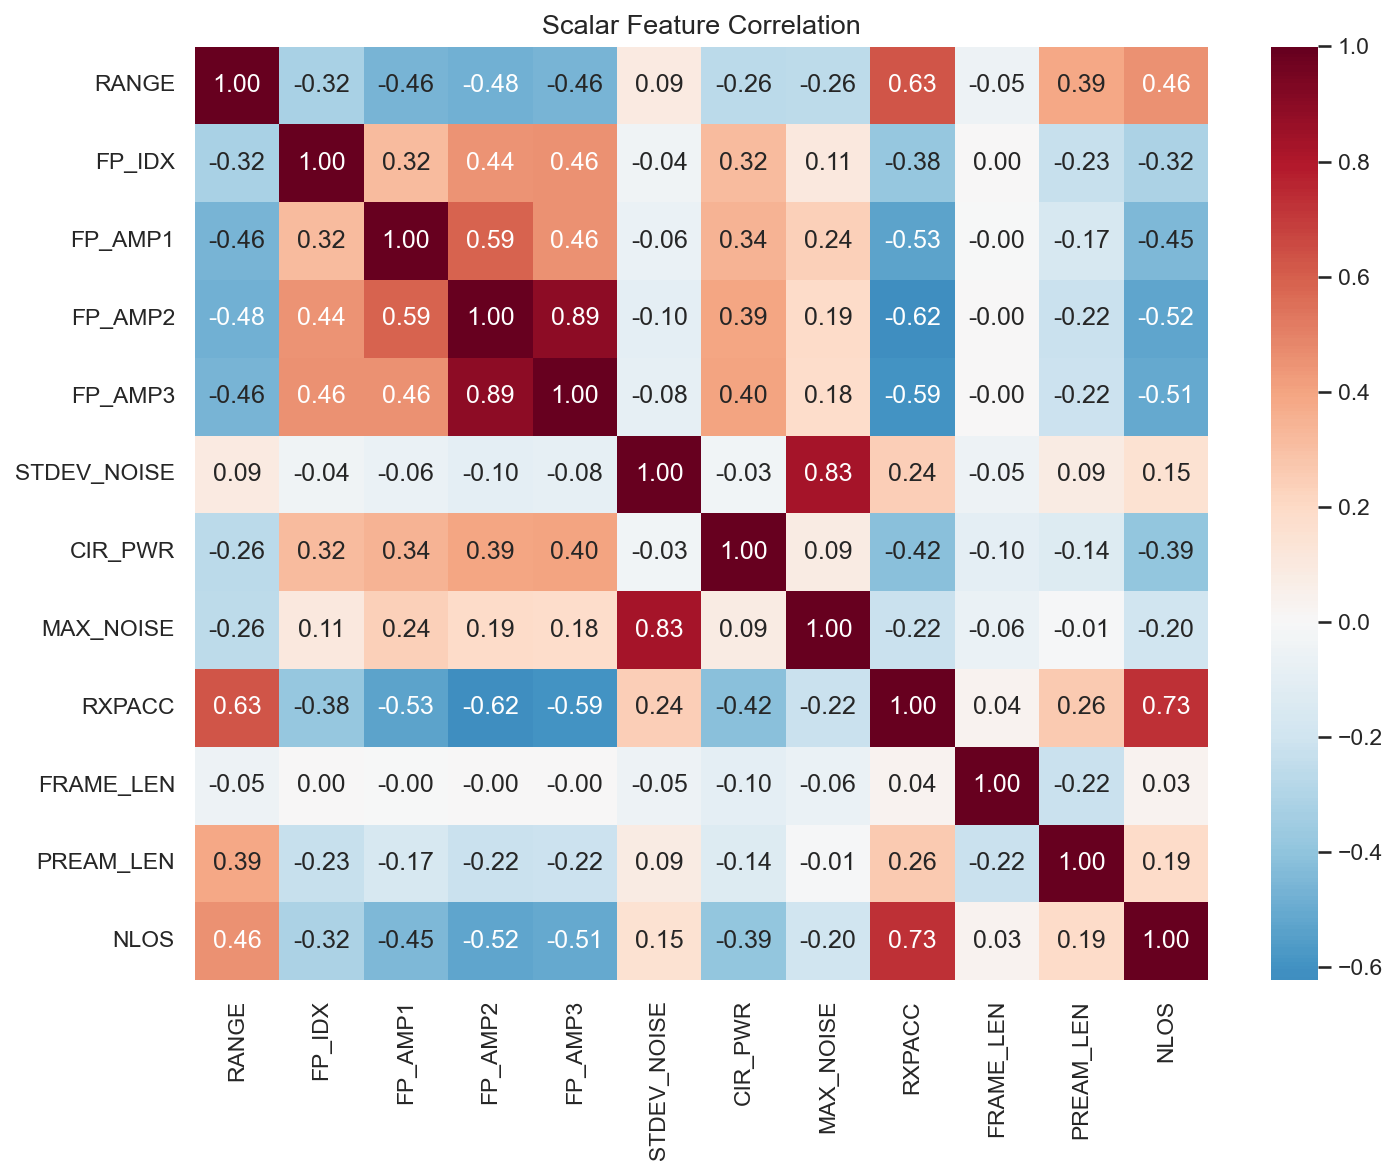

In [9]:
viz.plot_correlation_heatmap(df_raw)
show_plot('plots/03_correlation_heatmap.png', width=900)

  Saved: plots/04_cir_examples.png


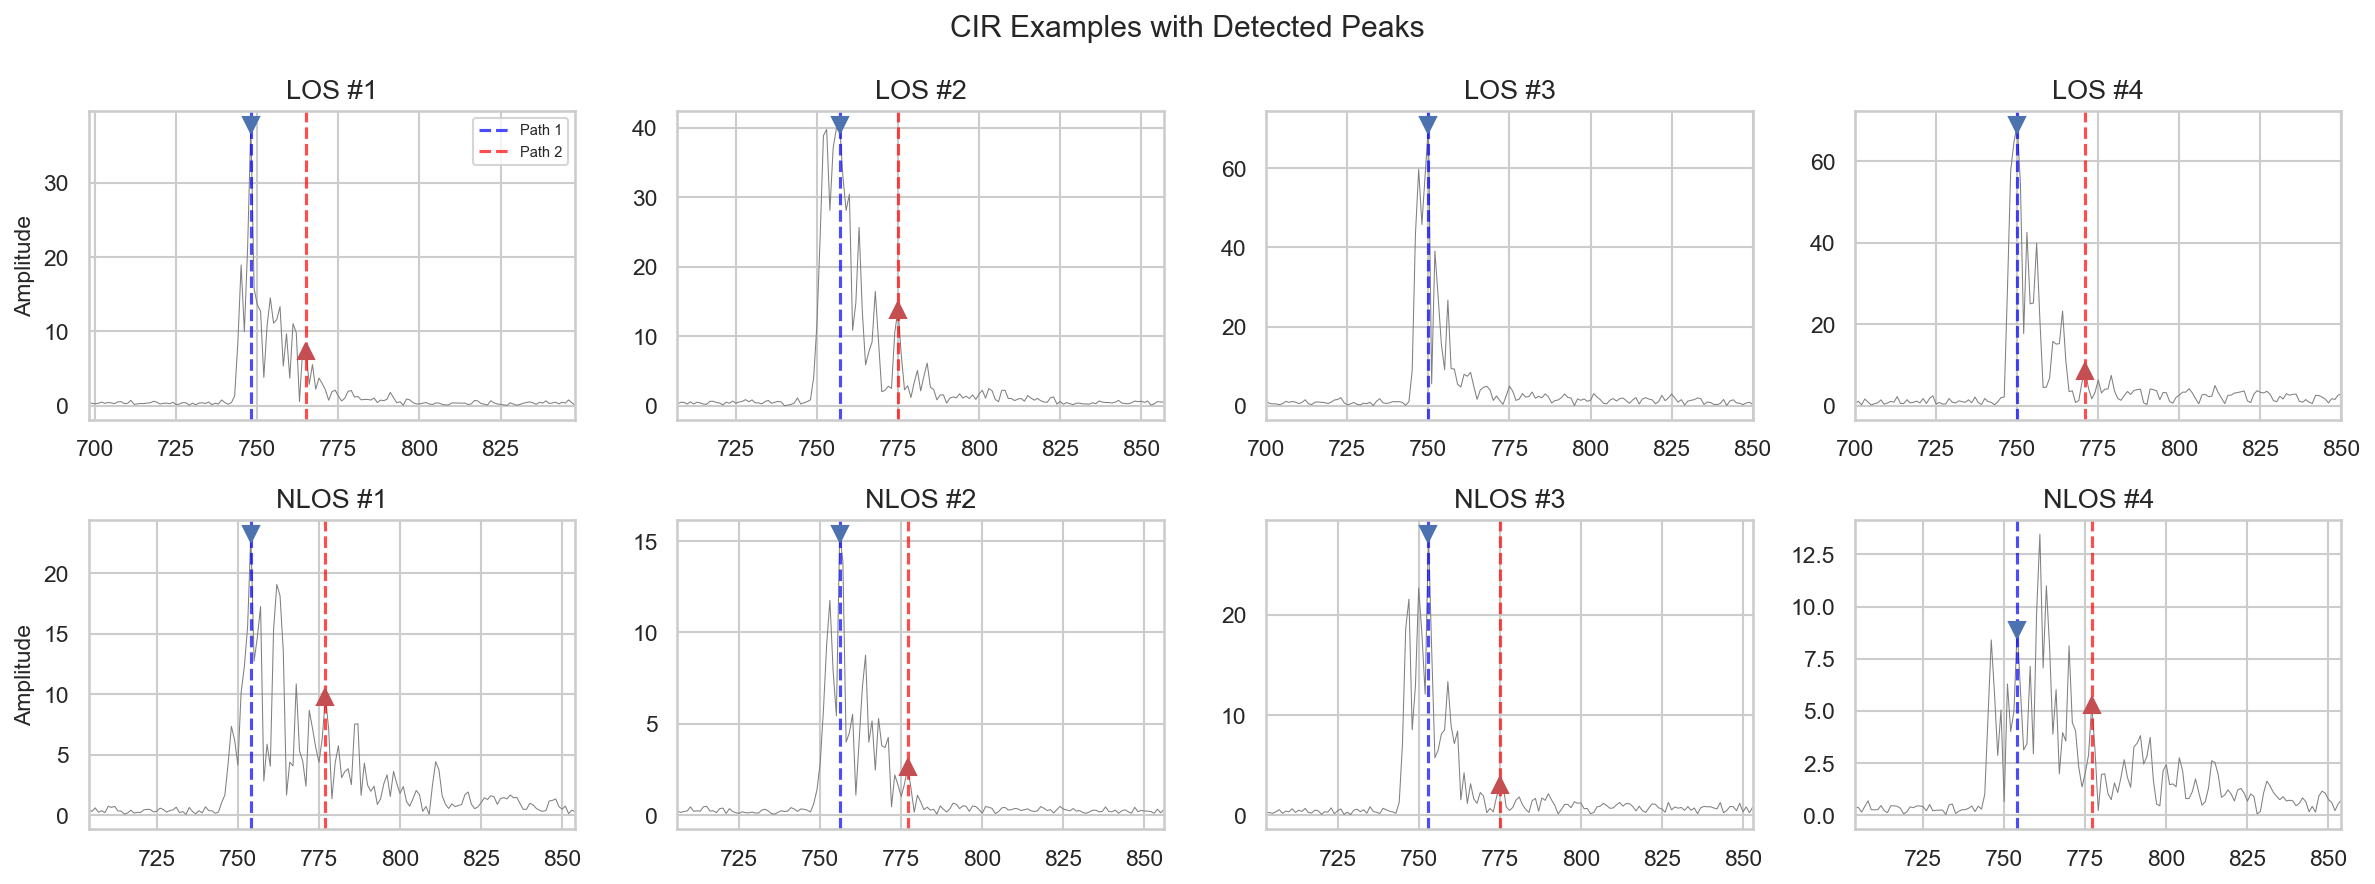

In [10]:
viz.plot_cir_examples(df, path1_idx, path1_amp, path2_idx, path2_amp)
show_plot('plots/04_cir_examples.png', width=1000)

  Saved: plots/05_fp_idx_distribution.png


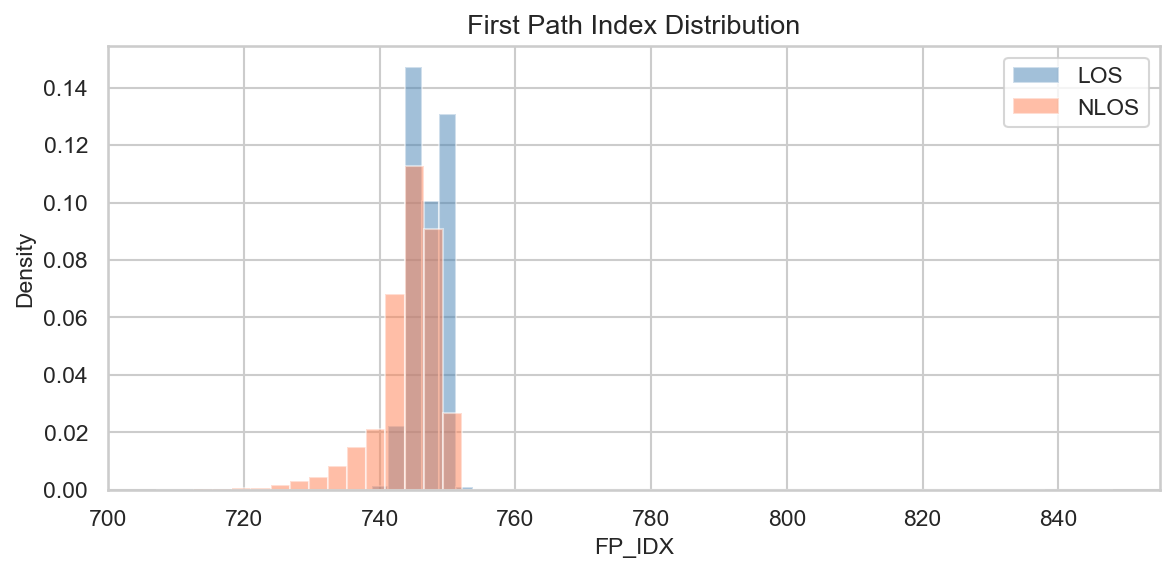

In [11]:
viz.plot_fp_idx_distribution(df_raw)
show_plot('plots/05_fp_idx_distribution.png', width=850)

## 5. Data Mining: Classification

### 5.1 Supervised Classification

The supervised classification stage compares linear, kernel, and ensemble learners on the 25-feature two-path representation. Logistic Regression provides a linear baseline, SVM with an RBF kernel captures non-linear decision boundaries, and Random Forest, Gradient Boosted Trees (implemented with `HistGradientBoostingClassifier`), and XGBoost (when available) model higher-order feature interactions expected in multipath CIR data. Grid search with stratified cross-validation tunes each model's hyperparameters, and class weighting addresses the NLOS-dominant imbalance produced by the two-path expansion.

In [12]:
# --- Train ML classifiers (timed) ---
print("=" * 60)
print("Training Feature-Engineered ML Models")
print("=" * 60)
t0 = time.time()
ml_results = train_classifiers(X_train_cls, y_train_cls, X_test_cls, y_test_cls)
ml_time = time.time() - t0
print(f"\nTotal ML training time: {ml_time:.1f}s")

# Alias for downstream cells that use the cls_results name
# (same dict reference, so .update() from build_ensemble propagates to both)
cls_results = ml_results


Training Feature-Engineered ML Models

--- Logistic Regression ---
  Accuracy: 0.9185, AUC: 0.9730
              precision    recall  f1-score   support

         LOS       0.77      0.96      0.86      4200
        NLOS       0.99      0.90      0.94     12600

    accuracy                           0.92     16800
   macro avg       0.88      0.93      0.90     16800
weighted avg       0.93      0.92      0.92     16800


--- SVM (RBF) (GridSearchCV, subsampled) ---
  Subsampled to 15000 training samples for SVM
Fitting 5 folds for each of 6 candidates, totalling 30 fits
  Best params: {'svm__C': 10, 'svm__gamma': 'scale'}
  Accuracy: 0.9262, AUC: 0.9735
              precision    recall  f1-score   support

         LOS       0.79      0.97      0.87      4200
        NLOS       0.99      0.91      0.95     12600

    accuracy                           0.93     16800
   macro avg       0.89      0.94      0.91     16800
weighted avg       0.94      0.93      0.93     16800


--- Rand

In [23]:
import torch
from src.dl_training import train_dl_classifier

cir_cols = [c for c in df.columns if c.startswith('CIR') and c != 'CIR_PWR']
X_cir_train   = df_scaled[cir_cols].values[train_idx]
X_cir_test    = df_scaled[cir_cols].values[test_idx]
X_scalar_train = df_scaled[SCALAR_FEATURES].values[train_idx]
X_scalar_test  = df_scaled[SCALAR_FEATURES].values[test_idx]
y_dl_train    = df_scaled['NLOS'].values[train_idx]
y_dl_test     = df_scaled['NLOS'].values[test_idx]

print(f"cir_cols:       {len(cir_cols)}  (expect 1016)")
print(f"X_cir_train:    {X_cir_train.shape}")
print(f"X_scalar_train: {X_scalar_train.shape}")
print(f"y_dl_train:     {y_dl_train.shape}")

cir_cols:       1016  (expect 1016)
X_cir_train:    (33596, 1016)
X_scalar_train: (33596, 11)
y_dl_train:     (33596,)


In [15]:
# --- Train DL model (timed) ---
print("=" * 60)
print("Training CNN+Transformer on Raw CIR")
print("=" * 60)
t0 = time.time()
dl_result = train_dl_classifier(
    X_cir_train, X_scalar_train, y_dl_train,
    X_cir_test, X_scalar_test, y_dl_test,
)
dl_time = time.time() - t0
print(f"\nDL training time: {dl_time:.1f}s")

Training CNN+Transformer on Raw CIR

--- CNN+Transformer (device: cuda, seed: 42) ---
  Epoch   1: train_loss=0.3852, val_loss=0.3365
  Epoch   5: train_loss=0.2910, val_loss=0.2778
  Epoch  10: train_loss=0.2503, val_loss=0.2015
  Epoch  15: train_loss=0.2292, val_loss=0.2194
  Epoch  20: train_loss=0.1960, val_loss=0.1913
  Early stopping at epoch 23
  Accuracy: 0.9368, AUC: 0.9827
              precision    recall  f1-score   support

         LOS       0.92      0.95      0.94      4200
        NLOS       0.95      0.92      0.94      4200

    accuracy                           0.94      8400
   macro avg       0.94      0.94      0.94      8400
weighted avg       0.94      0.94      0.94      8400


DL training time: 247.2s


## 4. Results Comparison

### 4.1 Summary Table

> **Important note on evaluation context**: The ML models are evaluated on the **two-path expanded** test set (16,800 samples, 25%/75% LOS/NLOS split), while the DL model is evaluated on the **original** test set (8,400 samples, 50/50 balanced). This difference in class distribution and dataset construction is itself a key finding — the DL model achieves competitive performance on a balanced, harder classification task without requiring domain-specific two-path expansion.

In [16]:
# Build comparison table
all_results = {**ml_results, 'CNN+Transformer': dl_result}

rows = []
for name, res in all_results.items():
    y_true = y_test_cls if name != 'CNN+Transformer' else y_dl_test
    y_pred = res['y_pred']
    rows.append({
        'Model': name,
        'Approach': 'Feature-Engineered ML' if name != 'CNN+Transformer' else 'End-to-End DL',
        'Accuracy': res['accuracy'],
        'AUC': res['auc'],
        'Precision (LOS)': precision_score(y_true, y_pred, pos_label=0),
        'Recall (LOS)': recall_score(y_true, y_pred, pos_label=0),
        'F1 (LOS)': f1_score(y_true, y_pred, pos_label=0),
        'Precision (NLOS)': precision_score(y_true, y_pred, pos_label=1),
        'Recall (NLOS)': recall_score(y_true, y_pred, pos_label=1),
        'F1 (NLOS)': f1_score(y_true, y_pred, pos_label=1),
        'F1 (macro)': f1_score(y_true, y_pred, average='macro'),
        'Test Samples': len(y_true),
    })

summary_df = pd.DataFrame(rows).set_index('Model')
summary_df.style.format({
    'Accuracy': '{:.4f}', 'AUC': '{:.4f}',
    'Precision (LOS)': '{:.4f}', 'Recall (LOS)': '{:.4f}', 'F1 (LOS)': '{:.4f}',
    'Precision (NLOS)': '{:.4f}', 'Recall (NLOS)': '{:.4f}', 'F1 (NLOS)': '{:.4f}',
    'F1 (macro)': '{:.4f}', 'Test Samples': '{:,}',
}).background_gradient(subset=['Accuracy', 'AUC', 'F1 (macro)'], cmap='Greens')

,Approach,Accuracy,AUC,Precision (LOS),Recall (LOS),F1 (LOS),Precision (NLOS),Recall (NLOS),F1 (NLOS),F1 (macro),Test Samples
Model,,,,,,,,,,,
Logistic Regression,Feature-Engineered ML,0.9185,0.9730,0.7686,0.9640,0.8553,0.9869,0.9033,0.9432,0.8993,"16,800"
SVM (RBF),Feature-Engineered ML,0.9262,0.9735,0.7868,0.9667,0.8675,0.9880,0.9127,0.9488,0.9082,"16,800"
Random Forest,Feature-Engineered ML,0.9396,0.9821,0.8398,0.9374,0.8859,0.9783,0.9404,0.9590,0.9224,"16,800"
Gradient Boosted Trees,Feature-Engineered ML,0.9312,0.9821,0.7988,0.9688,0.8756,0.9888,0.9187,0.9524,0.9140,"16,800"
XGBoost,Feature-Engineered ML,0.9398,0.9832,0.8401,0.9379,0.8863,0.9784,0.9405,0.9591,0.9227,"16,800"
CNN+Transformer,End-to-End DL,0.9368,0.9827,0.9232,0.9529,0.9378,0.9513,0.9207,0.9358,0.9368,"8,400"


### 4.2 ROC Curves

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: all models overlaid
ax = axes[0]
colors = {'Logistic Regression': '#4c72b0', 'Random Forest': '#55a868',
          'Gradient Boosted Trees': '#c44e52', 'CNN+Transformer': '#8172b2'}
for name, res in all_results.items():
    ax.plot(res['fpr'], res['tpr'], label=f"{name} (AUC={res['auc']:.4f})",
            color=colors.get(name, 'gray'), linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models')
ax.legend(fontsize=9)

# Right: zoomed into top-left corner
ax2 = axes[1]
for name, res in all_results.items():
    ax2.plot(res['fpr'], res['tpr'], label=f"{name}",
             color=colors.get(name, 'gray'), linewidth=2)
ax2.set_xlim(0, 0.15)
ax2.set_ylim(0.85, 1.0)
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curves — Zoomed (Top-Left Corner)')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

### 4.3 Confusion Matrices

In [27]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

for ax, (name, res) in zip(axes, all_results.items()):
    cm = res['confusion_matrix']
    # Normalize to percentages for fair comparison across different test set sizes
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=ax,
                xticklabels=['LOS', 'NLOS'], yticklabels=['LOS', 'NLOS'],
                cbar_kws={'label': '%'})
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    n_test = cm.sum()
    ax.set_title(f'{name}\n(n={n_test:,}, Acc={res["accuracy"]:.3f})')

fig.suptitle('Normalized Confusion Matrices (row %)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 4.4 Per-Class Performance Comparison

In [28]:
metrics = ['Accuracy', 'AUC', 'F1 (LOS)', 'F1 (NLOS)', 'F1 (macro)']
models = list(all_results.keys())

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(metrics))
width = 0.18
colors_bar = ['#4c72b0', '#55a868', '#c44e52', '#8172b2', '#ccb974', '#64b5cd', '#e377c2', '#7f7f7f'][:len(models)]

for i, model in enumerate(models):
    vals = [summary_df.loc[model, m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=model, color=colors_bar[i])
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics)
ax.set_ylim(0.8, 1.02)
ax.set_ylabel('Score')
ax.set_title('Per-Metric Model Comparison')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

### 4.5 Training Time Comparison

In [29]:
time_df = pd.DataFrame({
    'Pipeline': ['Feature-Engineered ML\n(LR + RF + GBT w/ GridSearch)', 'CNN+Transformer\n(end-to-end DL)'],
    'Training Time (s)': [ml_time, dl_time],
})

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(time_df['Pipeline'], time_df['Training Time (s)'],
               color=['#55a868', '#8172b2'], height=0.5)
for bar, t in zip(bars, time_df['Training Time (s)']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f'{t:.1f}s', va='center', fontsize=11)
ax.set_xlabel('Time (seconds)')
ax.set_title('Training Time Comparison')
plt.tight_layout()
plt.show()

print(f"ML pipeline total: {ml_time:.1f}s (includes GridSearchCV for RF and GBT)")
print(f"DL pipeline total: {dl_time:.1f}s (Adam + early stopping)")

ML pipeline total: 1298.8s (includes GridSearchCV for RF and GBT)
DL pipeline total: 247.2s (Adam + early stopping)


## 5. Interpretability Analysis

### 5.1 ML: Feature Importances (Random Forest)

In [30]:
feature_names = list(features_df.columns)
importances = ml_results['Random Forest']['feature_importances']
top_n = min(20, len(importances))
idx = np.argsort(importances)[::-1][:top_n]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(top_n), importances[idx[::-1]], color='#55a868')
ax.set_yticks(range(top_n))
ax.set_yticklabels([feature_names[i] for i in idx[::-1]])
ax.set_xlabel('Importance (Gini)')
ax.set_title(f'Top {top_n} Feature Importances — Random Forest')
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
for rank, i in enumerate(idx[:10], 1):
    print(f"  {rank:2d}. {feature_names[i]:25s} {importances[i]:.4f}")


Top 10 features:
   1. p_path_amp                0.2338
   2. p_peak_to_noise           0.1880
   3. p_energy_ratio            0.1158
   4. p_amplitude_ratio         0.0808
   5. p_path_idx                0.0704
   6. p_tail_energy_ratio       0.0499
   7. RXPACC                    0.0487
   8. p_rms_delay_spread        0.0301
   9. p_rise_time               0.0282
  10. p_mean_excess_delay       0.0242


### 5.2 DL: Transformer Attention Maps

The transformer's self-attention mechanism reveals which regions of the CIR waveform (after CNN encoding) the model focuses on when making LOS/NLOS decisions. Below we visualize attention weights upsampled back to the original CIR resolution for sample LOS and NLOS waveforms.

In [31]:
dl_model = dl_result['model']
device = next(dl_model.parameters()).device
dl_model.eval()

# Pick 3 LOS and 3 NLOS from test set
test_labels = df_scaled['NLOS'].values[test_idx]
los_samples = test_idx[test_labels == 0][:3]
nlos_samples = test_idx[test_labels == 1][:3]
sample_idxs = np.concatenate([los_samples, nlos_samples])
sample_labels = ['LOS'] * 3 + ['NLOS'] * 3

fig, axes = plt.subplots(2, 6, figsize=(24, 8))

for col, (idx, true_label) in enumerate(zip(sample_idxs, sample_labels)):
    cir_raw = df_scaled.iloc[idx][cir_cols].values.astype(float)
    cir_tensor = torch.tensor(cir_raw, dtype=torch.float32).unsqueeze(0).to(device)
    scalar_tensor = torch.tensor(
        df_scaled.iloc[idx][SCALAR_FEATURES].values.astype(float),
        dtype=torch.float32,
    ).unsqueeze(0).to(device)

    with torch.no_grad():
        logit = dl_model(cir_tensor, scalar_tensor)
        pred = 'NLOS' if logit.item() > 0 else 'LOS'

    # Get attention: [1, seq_len, seq_len] -> average over queries -> [seq_len]
    attn = dl_model.last_attention_weights
    if attn is not None:
        attn_avg = attn[0].mean(dim=0).cpu().numpy()
        attn_up = np.interp(np.linspace(0, 1, len(cir_raw)),
                            np.linspace(0, 1, len(attn_avg)), attn_avg)
    else:
        attn_up = np.zeros(len(cir_raw))

    # Top row: CIR waveform
    ax_top = axes[0, col]
    color = '#4c72b0' if true_label == 'LOS' else '#c44e52'
    ax_top.plot(cir_raw, color=color, linewidth=0.6, alpha=0.8)
    ax_top.fill_between(range(len(cir_raw)), 0, cir_raw, alpha=0.15, color=color)
    correct = '✓' if pred == true_label else '✗'
    ax_top.set_title(f'True: {true_label}, Pred: {pred} {correct}', fontsize=10)
    if col == 0:
        ax_top.set_ylabel('CIR Amplitude')

    # Bottom row: attention overlay
    ax_bot = axes[1, col]
    ax_bot.plot(cir_raw, color='gray', linewidth=0.4, alpha=0.5)
    ax_bot.fill_between(range(len(cir_raw)), 0, attn_up * cir_raw.max(),
                        alpha=0.6, color='orange')
    ax_bot.set_xlabel('CIR Index')
    if col == 0:
        ax_bot.set_ylabel('Attention × Max Amp')

fig.suptitle('Transformer Attention Maps on CIR Waveforms\n(Top: raw CIR, Bottom: attention-weighted)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 5.3 DL: CNN Feature Map Visualization

We can also visualize what the CNN encoder has learned by examining its intermediate feature maps for LOS vs NLOS inputs.

In [32]:
# Visualize CNN encoder output for a LOS vs NLOS sample
fig, axes = plt.subplots(2, 2, figsize=(14, 7))

for row, (idx, label) in enumerate([(los_samples[0], 'LOS'), (nlos_samples[0], 'NLOS')]):
    cir_raw = df_scaled.iloc[idx][cir_cols].values.astype(float)
    cir_tensor = torch.tensor(cir_raw, dtype=torch.float32).unsqueeze(0).to(device)  # [1, 1016]

    with torch.no_grad():
        x = cir_tensor.unsqueeze(1)          # [1, 1, 1016]
        x = dl_model.multi_scale(x)          # [1, 32, 1016]
        x = dl_model.pool1(x)                # [1, 32, 508]
        x = dl_model.res_block2(x)           # [1, 64, 254]
        cnn_out = dl_model.res_block3(x)     # [1, 128, 127]

    cnn_features = cnn_out[0].cpu().numpy()  # [128, 127]

    # Left: raw CIR
    axes[row, 0].plot(cir_raw, color='#4c72b0' if label == 'LOS' else '#c44e52', linewidth=0.8)
    axes[row, 0].set_title(f'{label} — Raw CIR')
    axes[row, 0].set_xlabel('CIR Sample Index')
    axes[row, 0].set_ylabel('Amplitude')

    # Right: CNN feature map heatmap (first 32 channels)
    im = axes[row, 1].imshow(cnn_features[:32], aspect='auto', cmap='viridis',
                              interpolation='nearest')
    axes[row, 1].set_title(f'{label} — CNN Feature Maps (channels 0-31)')
    axes[row, 1].set_xlabel('Temporal Position')
    axes[row, 1].set_ylabel('Channel')
    plt.colorbar(im, ax=axes[row, 1], shrink=0.8)

fig.suptitle('CNN Encoder Representations: LOS vs NLOS', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Error Analysis

### 6.1 Prediction Confidence Distribution

Examining the distribution of prediction probabilities reveals how confident each model is in its decisions.

In [33]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, res) in zip(axes, all_results.items()):
    y_true = y_test_cls if name != 'CNN+Transformer' else y_dl_test
    probs = res['y_prob']

    ax.hist(probs[y_true == 0], bins=50, alpha=0.6, color='#4c72b0', label='LOS', density=True)
    ax.hist(probs[y_true == 1], bins=50, alpha=0.6, color='#c44e52', label='NLOS', density=True)
    ax.axvline(0.5, color='black', linestyle='--', alpha=0.5, label='Threshold')
    ax.set_xlabel('P(NLOS)')
    ax.set_ylabel('Density')
    ax.set_title(name)
    ax.legend(fontsize=8)

fig.suptitle('Prediction Confidence Distribution by True Class', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 6.2 Misclassified Sample Analysis (CNN+Transformer)

Let's examine where the DL model fails — are there patterns in the misclassified CIR waveforms?

In [34]:
# Find misclassified samples
dl_pred = dl_result['y_pred']
dl_prob = dl_result['y_prob']
misclassified = test_idx[dl_pred != y_dl_test]
mis_true = y_dl_test[dl_pred != y_dl_test]
mis_prob = dl_prob[dl_pred != y_dl_test]

print(f"Total misclassified: {len(misclassified)} / {len(y_dl_test)} ({100*len(misclassified)/len(y_dl_test):.1f}%)")
print(f"  False Positives (LOS predicted as NLOS): {((mis_true == 0)).sum()}")
print(f"  False Negatives (NLOS predicted as LOS): {((mis_true == 1)).sum()}")

# Plot some misclassified examples
n_show = min(6, len(misclassified))
fig, axes = plt.subplots(2, n_show, figsize=(4 * n_show, 7))

for col in range(n_show):
    idx = misclassified[col]
    cir_raw = df_scaled.iloc[idx][cir_cols].values.astype(float)
    true = 'NLOS' if y_dl_test[dl_pred != y_dl_test][col] == 1 else 'LOS'
    pred = 'NLOS' if dl_pred[dl_pred != y_dl_test][col] == 1 else 'LOS'
    prob = mis_prob[col]

    # CIR waveform
    color = '#c44e52' if true == 'NLOS' else '#4c72b0'
    axes[0, col].plot(cir_raw, color=color, linewidth=0.6)
    axes[0, col].set_title(f'True: {true}, Pred: {pred}\nP(NLOS)={prob:.3f}', fontsize=9)
    if col == 0:
        axes[0, col].set_ylabel('CIR Amplitude')

    # Attention for this sample
    cir_tensor = torch.tensor(cir_raw, dtype=torch.float32).unsqueeze(0).to(device)
    scalar_tensor = torch.tensor(
        df_scaled.iloc[idx][SCALAR_FEATURES].values.astype(float),
        dtype=torch.float32,
    ).unsqueeze(0).to(device)
    with torch.no_grad():
        dl_model(cir_tensor, scalar_tensor)
    attn = dl_model.last_attention_weights
    if attn is not None:
        attn_avg = attn[0].mean(dim=0).cpu().numpy()
        attn_up = np.interp(np.linspace(0, 1, len(cir_raw)),
                            np.linspace(0, 1, len(attn_avg)), attn_avg)
    else:
        attn_up = np.zeros(len(cir_raw))

    axes[1, col].plot(cir_raw, color='gray', linewidth=0.4, alpha=0.5)
    axes[1, col].fill_between(range(len(cir_raw)), 0, attn_up * cir_raw.max(),
                               alpha=0.6, color='orange')
    axes[1, col].set_xlabel('CIR Index')
    if col == 0:
        axes[1, col].set_ylabel('Attention')

fig.suptitle('Misclassified Samples — CNN+Transformer\n(Top: CIR, Bottom: Attention)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

Total misclassified: 531 / 8400 (6.3%)
  False Positives (LOS predicted as NLOS): 198
  False Negatives (NLOS predicted as LOS): 333


### 6.3 Error Rate by Signal Characteristics

Do models struggle more at certain ranges or noise levels?

In [35]:
# Analyze DL errors by RANGE and STDEV_NOISE
test_df = df.iloc[test_idx].copy()
test_df['correct'] = (dl_pred == y_dl_test).astype(int)
test_df['true_label'] = y_dl_test

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

# Error rate by range bins
test_df['range_bin'] = pd.cut(test_df['RANGE'], bins=10)
err_by_range = test_df.groupby('range_bin', observed=True)['correct'].agg(['mean', 'count'])
ax = axes[0]
ax.bar(range(len(err_by_range)), 1 - err_by_range['mean'], color='#c44e52', alpha=0.7)
ax.set_xticks(range(len(err_by_range)))
ax.set_xticklabels([f'{iv.mid:.1f}' for iv in err_by_range.index], rotation=45, fontsize=8)
ax.set_xlabel('Range (m)')
ax.set_ylabel('Error Rate')
ax.set_title('DL Error Rate by Range')

# Error rate by noise bins
test_df['noise_bin'] = pd.cut(test_df['STDEV_NOISE'], bins=10)
err_by_noise = test_df.groupby('noise_bin', observed=True)['correct'].agg(['mean', 'count'])
ax = axes[1]
ax.bar(range(len(err_by_noise)), 1 - err_by_noise['mean'], color='#8172b2', alpha=0.7)
ax.set_xticks(range(len(err_by_noise)))
ax.set_xticklabels([f'{iv.mid:.0f}' for iv in err_by_noise.index], rotation=45, fontsize=8)
ax.set_xlabel('STDEV_NOISE')
ax.set_ylabel('Error Rate')
ax.set_title('DL Error Rate by Noise Level')

# Error rate by CIR power bins
test_df['pwr_bin'] = pd.cut(test_df['CIR_PWR'], bins=10)
err_by_pwr = test_df.groupby('pwr_bin', observed=True)['correct'].agg(['mean', 'count'])
ax = axes[2]
ax.bar(range(len(err_by_pwr)), 1 - err_by_pwr['mean'], color='#55a868', alpha=0.7)
ax.set_xticks(range(len(err_by_pwr)))
ax.set_xticklabels([f'{iv.mid:.0f}' for iv in err_by_pwr.index], rotation=45, fontsize=8)
ax.set_xlabel('CIR_PWR')
ax.set_ylabel('Error Rate')
ax.set_title('DL Error Rate by CIR Power')

fig.suptitle('CNN+Transformer Error Analysis by Signal Characteristics', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 7. Model Complexity Comparison

In [48]:
# Model parameter counts
dl_params = sum(p.numel() for p in dl_model.parameters())
dl_trainable = sum(p.numel() for p in dl_model.parameters() if p.requires_grad)

rf_model = ml_results['Random Forest']['model']
# Approximate RF complexity: n_estimators * n_nodes * features
rf_estimators = rf_model.n_estimators
rf_total_nodes = sum(est.tree_.node_count for est in rf_model.estimators_)

gbt_model = ml_results['Gradient Boosted Trees']['model']
gbt_estimators = gbt_model.n_iter_  # HistGBT uses n_iter_, not n_estimators
try:
    gbt_total_nodes = sum(
        predictor.get_n_leaf_nodes()
        for predictor_list in gbt_model._predictors
        for predictor in predictor_list
    )
except Exception:
    gbt_total_nodes = gbt_estimators * 50  # approximate

complexity_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosted Trees', 'CNN+Transformer'],
    'Type': ['Linear', 'Ensemble (bagging)', 'Ensemble (boosting)', 'Neural Network'],
    'Parameters / Nodes': [
        f'{X_train_cls.shape[1] + 1:,} weights',
        f'{rf_total_nodes:,} nodes ({rf_estimators} trees)',
        f'{gbt_total_nodes:,} nodes ({gbt_estimators} trees)',
        f'{dl_params:,} parameters',
    ],
    'Input Dim': [25, 25, 25, 1027],
    'Feature Eng. Required': ['Yes (25 features)', 'Yes (25 features)', 'Yes (25 features)', 'No (raw CIR)'],
    'Hardware': ['CPU', 'CPU (parallel)', 'CPU', 'GPU/MPS preferred'],
}
# --- Recursive Feature Elimination with Cross-Validation ---
# This block was missing from the notebook but was referenced
# below via rfecv.support_ / rfecv.n_features_ (and rfe_results
# in a later plotting cell). Mirrors main.py Step 5a.
best_rf = cls_results['Random Forest']['model']
rfecv = RFECV(
    estimator=best_rf, step=1, cv=3, scoring='accuracy',
    min_features_to_select=1, n_jobs=-1,
)
rfecv.fit(X_train_cls, y_train_cls)
rfe_results = {
    'n_features': np.arange(1, len(rfecv.ranking_) + 1),
    'scores': rfecv.cv_results_['mean_test_score'],
}
print(f'RFECV optimal number of features: {rfecv.n_features_}')

selected_features = [name for name, keep in zip(feature_names, rfecv.support_) if keep]

print(f'Optimal number of features: {rfecv.n_features_}')
print('Top selected features:')
for name in selected_features[:15]:
    print(f'  - {name}')

RFECV optimal number of features: 2
Optimal number of features: 2
Top selected features:
  - p_path_amp
  - p_peak_to_noise


### 5.3 Ensemble Stacking

Ensembling tests whether complementary decision boundaries from the strongest tree-based models can be combined to produce a more stable classifier. A simple averaging ensemble reduces model-specific variance, while stacked generalization trains a logistic-regression meta-learner on out-of-fold probability predictions to learn the optimal combination weights. This extension is motivated by the observation that LOS/NLOS ambiguity often arises in borderline multipath cases where different learners make different but informative errors.

In [42]:
ensemble_results = build_ensemble(
    cls_results, X_train_cls, y_train_cls, X_test_cls, y_test_cls,
)
cls_results.update(ensemble_results)

# Parameter breakdown by component
cnn_params = (
    sum(p.numel() for p in dl_model.multi_scale.parameters()) +
    sum(p.numel() for p in dl_model.res_block2.parameters()) +
    sum(p.numel() for p in dl_model.res_block3.parameters())
)
transformer_params = sum(p.numel() for p in dl_model.transformer.parameters())
head_params = sum(p.numel() for p in dl_model.head.parameters())
pe_params = sum(p.numel() for p in dl_model.pos_enc.parameters())

ensemble_summary = pd.DataFrame([
    {'Model': name, 'Accuracy': res['accuracy'], 'AUC': res['auc']}
    for name, res in ensemble_results.items()
])
display(ensemble_summary.style.format({'Accuracy': '{:.4f}', 'AUC': '{:.4f}'}))


--- Ensemble (3 models: Random Forest, Gradient Boosted Trees, XGBoost) ---
  Ensemble (Average): Accuracy=0.9399, AUC=0.9832
              precision    recall  f1-score   support

         LOS       0.83      0.95      0.89      4200
        NLOS       0.98      0.93      0.96     12600

    accuracy                           0.94     16800
   macro avg       0.91      0.94      0.92     16800
weighted avg       0.95      0.94      0.94     16800

  Ensemble (Stacked): Accuracy=0.9413, AUC=0.9829
              precision    recall  f1-score   support

         LOS       0.85      0.93      0.89      4200
        NLOS       0.97      0.95      0.96     12600

    accuracy                           0.94     16800
   macro avg       0.91      0.94      0.92     16800
weighted avg       0.94      0.94      0.94     16800



,Model,Accuracy,AUC
0,Ensemble (Average),0.9399,0.9832
1,Ensemble (Stacked),0.9413,0.9829


## 6. Deep Learning: CNN+Transformer (Pre-computed Results)

The deep learning pipeline applies a hybrid architecture that processes raw CIR waveforms without hand-crafted features. The model consists of a multi-scale first convolution (kernels of size 3, 7, and 15) followed by two residual CNN blocks (32 to 64 to 128 channels), a 2-layer Transformer encoder with 4 attention heads, global average pooling, and a final MLP classification head that also ingests the 11 scalar features. Because full training is computationally expensive (requiring GPU or Apple MPS acceleration), this notebook presents the deep-learning results as a static summary from the most recent `main.py` pipeline run rather than executing training inline.

Deep Learning Results (pre-computed):
                    Model  Accuracy    AUC                        Training Set                         Training
          CNN+Transformer    0.9368 0.9827      ~33.6K (original, 80/20 split) Adam + early stopping, 30 epochs
CNN+Transformer + CIR Aug    0.9387 0.9862 ~134K (3x augmented training split) Adam + early stopping, 30 epochs

--- Transformer Attention Maps (pre-generated by main.py) ---


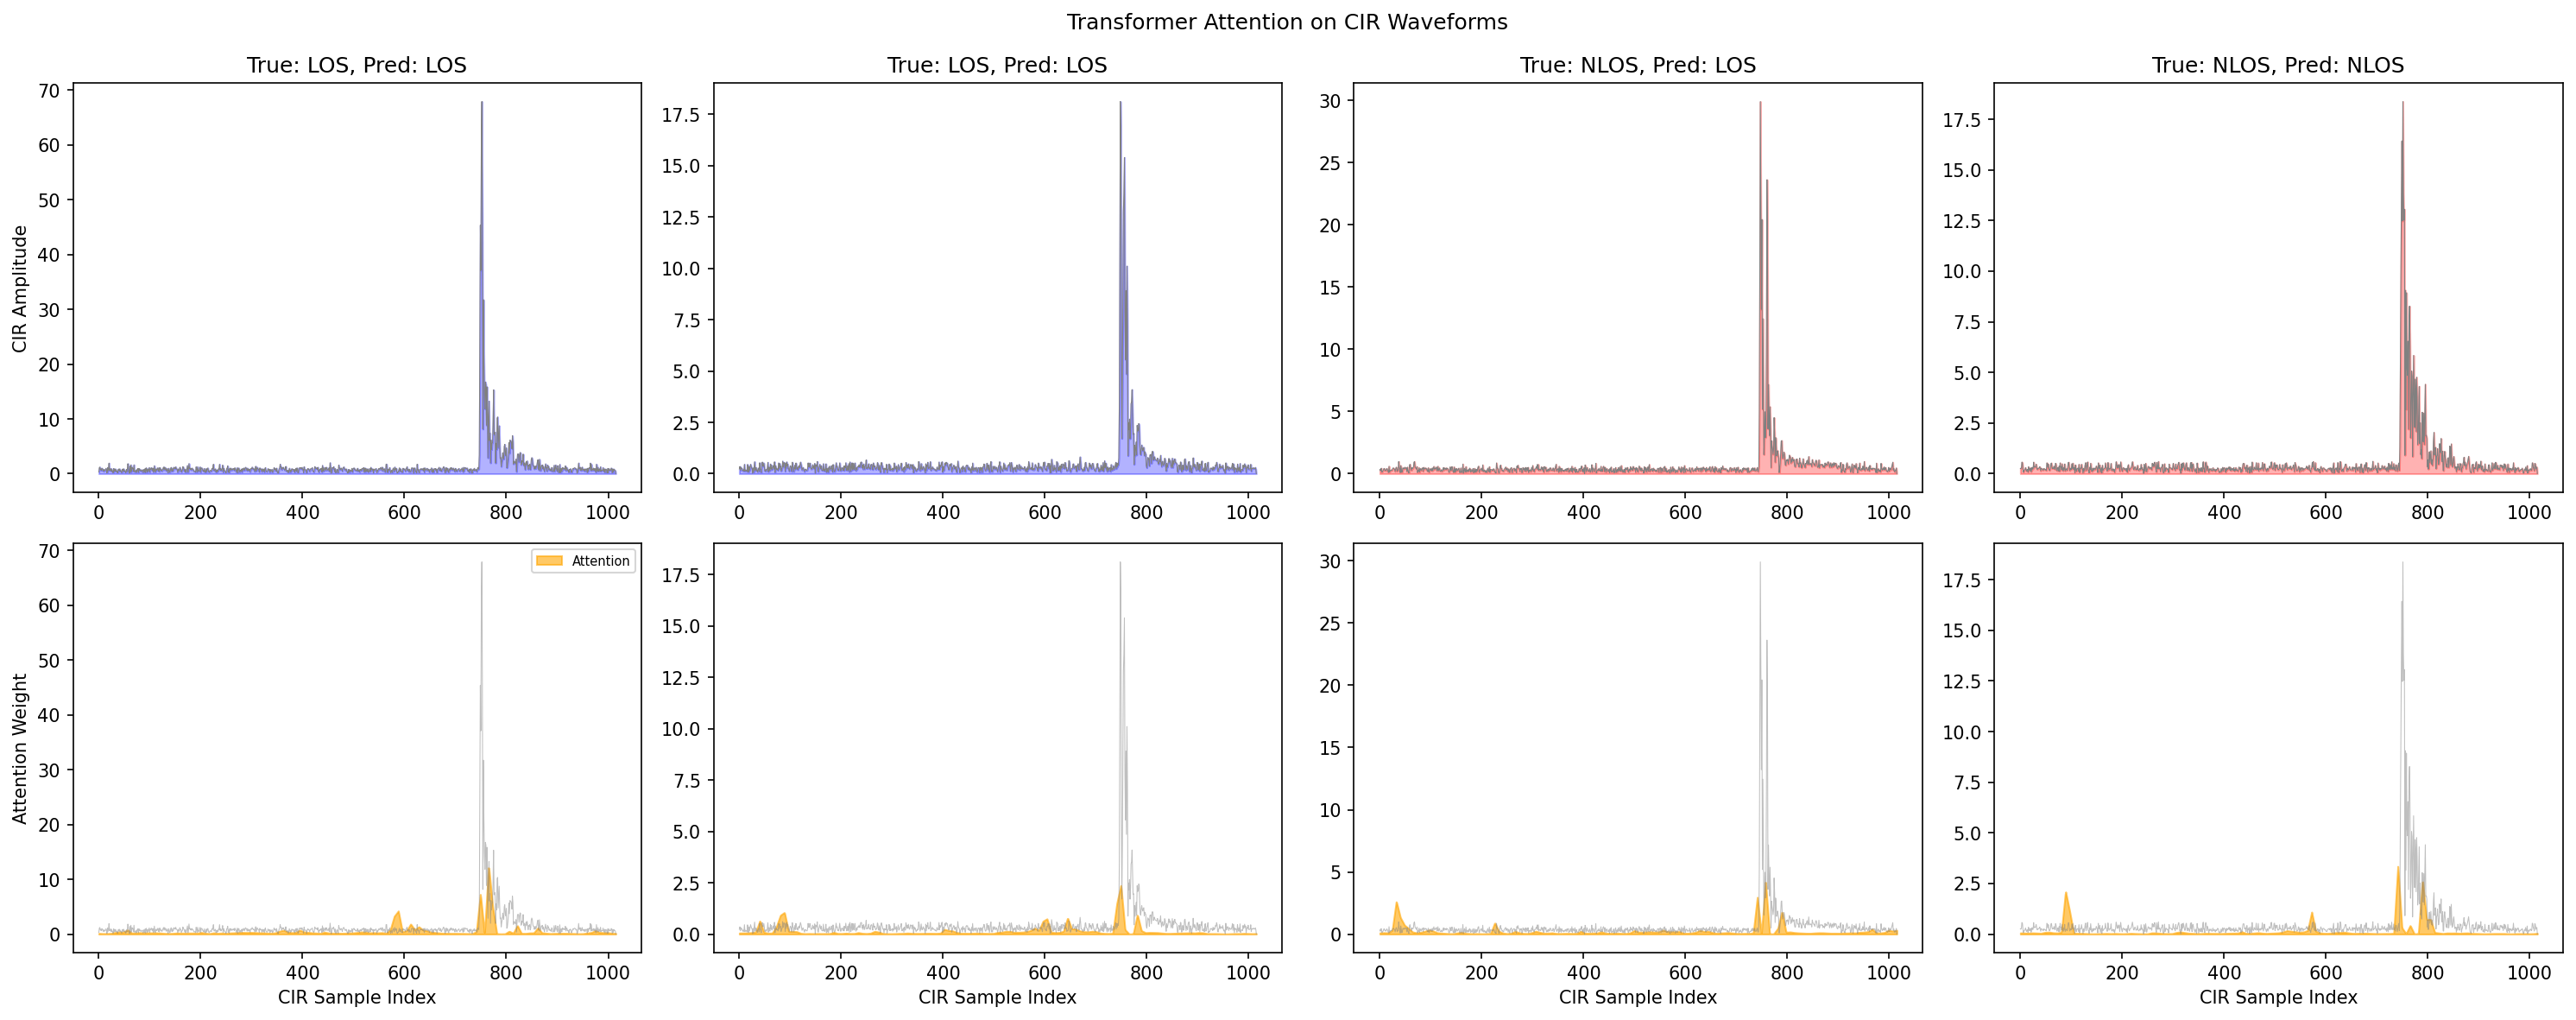

In [43]:
# Deep Learning results are pre-computed because CNN+Transformer training
# requires GPU/MPS hardware and takes several minutes per run.

dl_metrics = pd.DataFrame({
    'Model': ['CNN+Transformer', 'CNN+Transformer + CIR Aug'],
    'Accuracy': [0.9368, 0.9387],
    'AUC': [0.9827, 0.9862],
    'Training Set': ['~33.6K (original, 80/20 split)', '~134K (3x augmented training split)'],
    'Training': ['Adam + early stopping, 30 epochs', 'Adam + early stopping, 30 epochs'],
})
print('Deep Learning Results (pre-computed):')
print(dl_metrics.to_string(index=False))

print('\n--- Transformer Attention Maps (pre-generated by main.py) ---')
show_plot('plots/13_attention_map.png', width=1000)

## 7. Data Mining: Regression

Beyond binary classification, the project estimates geometric distance for the two dominant paths. Path 1 uses the measured `RANGE` target directly, while the Path 2 target is derived from the additional CIR delay relative to `FP_IDX`: measured range plus the temporal offset multiplied by the speed of light ($c \approx 0.2998$ m/ns). This regression task is analytically important because precise path-wise ranging is a prerequisite for multipath-aware indoor positioning.

In [47]:
# Path 1 regression
p1_mask_train = exp_train_idx[exp_train_idx < n_orig]
p1_mask_test = exp_test_idx[exp_test_idx < n_orig]
X_train_p1 = features_df.iloc[p1_mask_train].values
y_train_p1 = labels_range[p1_mask_train]
X_test_p1 = features_df.iloc[p1_mask_test].values
y_test_p1 = labels_range[p1_mask_test]

print('>> Path 1 Distance Estimation')
reg_results_p1 = train_regressors(
    X_train_p1, y_train_p1, X_test_p1, y_test_p1, 'Path 1',
)

reg_summary_p1 = pd.DataFrame([
    {'Model': name, 'RMSE (m)': res['rmse'], 'MAE (m)': res['mae'], 'R-squared': res['r2']}
    for name, res in reg_results_p1.items()
]).sort_values('RMSE (m)')
display(reg_summary_p1.style.format({'RMSE (m)': '{:.4f}', 'MAE (m)': '{:.4f}', 'R-squared': '{:.4f}'}))

>> Path 1 Distance Estimation

--- Ridge Regression (Path 1) ---
  RMSE: 1.6164 m, MAE: 1.2399 m, R²: 0.5407

--- Random Forest Regressor (GridSearchCV) (Path 1) ---
Fitting 3 folds for each of 8 candidates, totalling 24 fits


KeyboardInterrupt: 

In [ ]:
# Path 2 regression
p2_mask_train = exp_train_idx[exp_train_idx >= n_orig] - n_orig
p2_mask_test = exp_test_idx[exp_test_idx >= n_orig] - n_orig

X_train_p2_base = features_df.iloc[p2_mask_train + n_orig].values
X_test_p2_base = features_df.iloc[p2_mask_test + n_orig].values
range_train = df['RANGE'].values[p2_mask_train].reshape(-1, 1)
range_test = df['RANGE'].values[p2_mask_test].reshape(-1, 1)
X_train_p2 = np.hstack([X_train_p2_base, range_train])
X_test_p2 = np.hstack([X_test_p2_base, range_test])
y_train_p2 = labels_range[p2_mask_train + n_orig]
y_test_p2 = labels_range[p2_mask_test + n_orig]

# Filter out samples where Path 2 was not detected
valid_train = path2_amp[p2_mask_train] > 0
valid_test = path2_amp[p2_mask_test] > 0
print(f'Path 2 valid samples: train={valid_train.sum()}, test={valid_test.sum()}')

print('\n>> Path 2 Distance Estimation')
reg_results_p2 = train_regressors(
    X_train_p2[valid_train], y_train_p2[valid_train],
    X_test_p2[valid_test], y_test_p2[valid_test], 'Path 2',
)

reg_summary_p2 = pd.DataFrame([
    {'Model': name, 'RMSE (m)': res['rmse'], 'MAE (m)': res['mae'], 'R-squared': res['r2']}
    for name, res in reg_results_p2.items()
]).sort_values('RMSE (m)')
display(reg_summary_p2.style.format({'RMSE (m)': '{:.4f}', 'MAE (m)': '{:.4f}', 'R-squared': '{:.4f}'}))

## 8. Data Mining: Unsupervised Clustering

Clustering provides an unsupervised baseline for evaluating whether the engineered feature space naturally separates LOS and NLOS behaviour without using labels. K-Means with $k = 2$ tests the strongest two-group partition, elbow and silhouette analyses assess whether that choice is structurally reasonable, and DBSCAN adds a density-based perspective that can identify ambiguous or noisy measurements. Within the 3D framework, this stage supports result analysis by verifying that the supervised classifiers exploit an intrinsically meaningful feature-space geometry rather than overfitting to label-specific artifacts.

In [46]:
cluster_results = run_kmeans_analysis(X_train_cls, y_train_cls, X_test_cls, y_test_cls)
elbow_results = run_elbow_silhouette_analysis(X_train_cls)
dbscan_results = run_dbscan_analysis(X_train_cls, X_test_cls, y_test_cls)


--- K-Means Clustering (k=2) ---
  Train accuracy (best mapping): 0.5728
  Test accuracy  (best mapping): 0.5700
  Silhouette score (train): 0.2027
  Silhouette score (test):  0.2088
  Adjusted Rand Index: -0.0099
  PCA explained variance: 40.77%

--- Elbow / Silhouette Analysis ---
    k       Inertia  Silhouette
  ---  ------------  ----------
    2      192659.4      0.2027
    3      161861.7      0.2109
    4      147748.1      0.2264
    5      136490.6      0.1919
    6      129572.8      0.1596
    7      120264.2      0.1792
    8      114182.3      0.1870
    9      110419.6      0.1703
   10      106892.2      0.1698

--- DBSCAN Clustering (eps=2.0, min_samples=10) ---
  Clusters found: 9
  Noise points: 2133 (12.7%)
  Accuracy (non-noise only): 0.5263


## 9. Synthetic Data Augmentation

Two augmentation strategies are evaluated for robustness analysis. SMOTE generates synthetic minority-class feature vectors by interpolating between existing LOS samples and their nearest neighbours, partially rebalancing the two-path dataset (here with `target_ratio=0.5`, i.e. partial rather than full rebalancing). This runs inline because it operates on the tabular feature matrix and completes quickly. By contrast, raw-CIR waveform augmentation for the CNN+Transformer is shown only through pre-computed results because generating large augmented waveform sets and retraining the deep model is substantially more expensive.

>> SMOTE augmentation for ML classifiers
  SMOTE: Generated 8397 synthetic LOS samples
  Class distribution: LOS=25196, NLOS=50393
  RF + SMOTE: Accuracy=0.9395, AUC=0.9816
  RF original: Accuracy=0.9396, AUC=0.9821
  Delta: Accuracy=-0.0001, AUC=-0.0006

--- Augmentation Impact (ML + DL comparison, DL pre-computed by main.py) ---


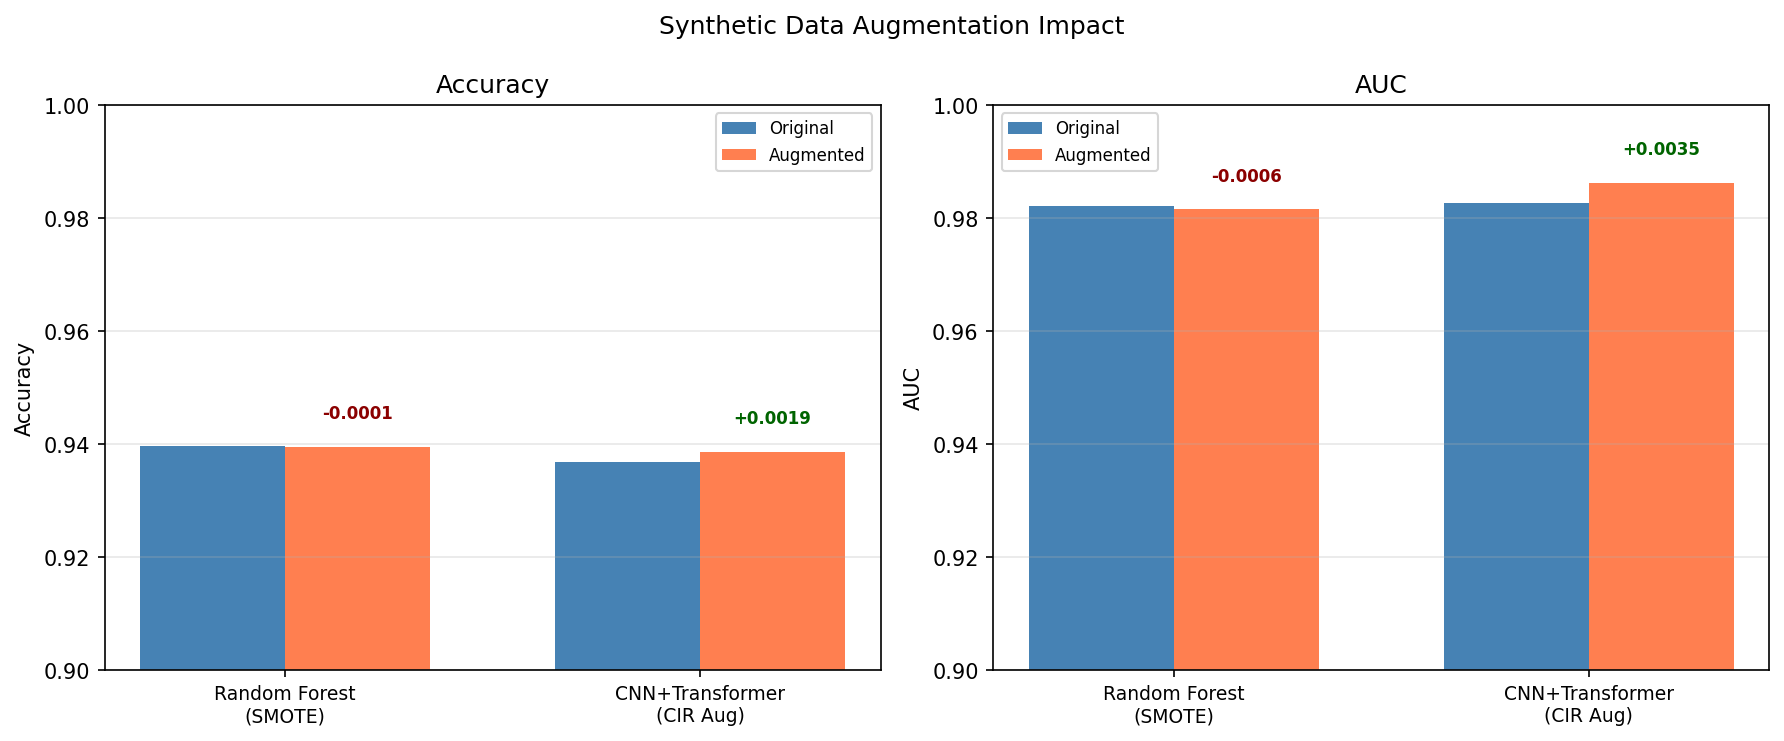

In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc as sk_auc

print('>> SMOTE augmentation for ML classifiers')
X_smote, y_smote, n_smote = apply_smote(X_train_cls, y_train_cls, target_ratio=0.5)

# Re-train Random Forest with SMOTE-augmented data
rf_smote = RandomForestClassifier(
    n_estimators=300, max_depth=None, class_weight='balanced', random_state=42,
)
rf_smote.fit(X_smote, y_smote)
y_pred_smote = rf_smote.predict(X_test_cls)
y_prob_smote = rf_smote.predict_proba(X_test_cls)[:, 1]
acc_smote = accuracy_score(y_test_cls, y_pred_smote)
fpr_s, tpr_s, _ = roc_curve(y_test_cls, y_prob_smote)
auc_smote = sk_auc(fpr_s, tpr_s)
print(f'  RF + SMOTE: Accuracy={acc_smote:.4f}, AUC={auc_smote:.4f}')
print(f"  RF original: Accuracy={cls_results['Random Forest']['accuracy']:.4f}, "
      f"AUC={cls_results['Random Forest']['auc']:.4f}")
delta_acc = acc_smote - cls_results['Random Forest']['accuracy']
delta_auc = auc_smote - cls_results['Random Forest']['auc']
print(f'  Delta: Accuracy={delta_acc:+.4f}, AUC={delta_auc:+.4f}')

print('\n--- Augmentation Impact (ML + DL comparison, DL pre-computed by main.py) ---')
show_plot('plots/24_augmentation_impact.png', width=850)

The inline SMOTE experiment typically produces only a marginal change in Random Forest performance because the expanded training set is already large and the minority LOS class is still well represented in absolute terms. In contrast, the pre-computed deep-learning results indicate that waveform-level augmentation yields a more noticeable gain for the CNN+Transformer, suggesting that sequence-level models benefit more from local perturbation diversity than tree ensembles operating on already distilled features. This comparison suggests that the value of augmentation depends on the representation being learned rather than on augmentation alone.

## 10. Data Visualization: Mining and Results

The following figures summarize the outputs of the Data Mining stage and connect them to domain interpretation. They cover model interpretability (feature importance, SHAP), discrimination quality (ROC, PR, confusion matrices), environment-specific behaviour, unsupervised structure, and range-estimation error patterns. Each utility function saves a figure to disk and the saved PNG is then displayed inline.

In [ ]:
# Feature importance
if 'feature_importances' in cls_results.get('Random Forest', {}):
    viz.plot_feature_importance(
        cls_results['Random Forest']['feature_importances'],
        feature_names,
    )
    show_plot('plots/06_feature_importance.png', width=900)

In [ ]:
# SHAP summary plots
viz.plot_shap_summary(cls_results, X_test_cls, feature_names)
try:
    show_plot('plots/20_shap_beeswarm.png', width=950)
except FileNotFoundError:
    print('SHAP beeswarm plot not generated.')

In [ ]:
try:
    show_plot('plots/21_shap_bar.png', width=850)
except FileNotFoundError:
    print('SHAP bar plot not generated.')

In [ ]:
# Classification performance plots
viz.plot_confusion_matrices(cls_results, y_test_cls)
show_plot('plots/07_confusion_matrices.png', width=1050)

In [ ]:
viz.plot_roc_curves(cls_results)
show_plot('plots/08_roc_curves.png', width=900)

In [ ]:
viz.plot_pr_curves(cls_results, y_test_cls)
show_plot('plots/15_pr_curves.png', width=900)

In [ ]:
viz.plot_model_comparison(cls_results)
show_plot('plots/09_model_comparison.png', width=850)

In [ ]:
viz.plot_per_environment_heatmap(cls_results, X_test_cls, y_test_cls, env_ids_test)
show_plot('plots/16_per_environment_heatmap.png', width=1000)

In [ ]:
viz.plot_rfe_curve(rfe_results)
show_plot('plots/22_rfe_curve.png', width=850)

In [ ]:
# Clustering visualizations
viz.plot_clustering(cluster_results, y_test_cls)
show_plot('plots/14_clustering.png', width=950)

In [ ]:
viz.plot_elbow_silhouette(elbow_results)
show_plot('plots/19_elbow_silhouette.png', width=850)

In [ ]:
viz.plot_tsne_embedding(X_test_cls, y_test_cls, cluster_results['test_labels'])
show_plot('plots/18_tsne_embedding.png', width=1000)

In [ ]:
viz.plot_dbscan(dbscan_results, y_test_cls)
show_plot('plots/23_dbscan.png', width=950)

In [ ]:
# Regression and annotated CIR plots
viz.plot_predicted_vs_actual(reg_results_p1, y_test_p1, reg_results_p2, y_test_p2[valid_test])
show_plot('plots/10_predicted_vs_actual.png', width=950)

In [ ]:
viz.plot_residuals(reg_results_p1, y_test_p1, reg_results_p2, y_test_p2[valid_test])
show_plot('plots/11_residuals.png', width=950)

In [ ]:
viz.plot_regression_comparison(reg_results_p1, reg_results_p2)
show_plot('plots/17_regression_comparison.png', width=1000)

In [ ]:
viz.plot_annotated_cir(df, path1_idx, path1_amp, path2_idx, path2_amp, cls_results, features_df)
show_plot('plots/12_annotated_cir.png', width=950)

## 11. Results Analysis and Discussion

### 11.1 Classification Summary

The inline classification results on the expanded two-path tabular dataset show a clear pattern: tree-based models are the strongest supervised learners for this notebook's LOS/NLOS task, consistent with a strongly non-linear decision boundary in the engineered feature space. The summary table above (generated from `cls_results`) gives the exact notebook-computed metrics for all supervised and ensemble classifiers. Key observations:

- Logistic Regression serves as a useful linear baseline but underfits the non-linear multipath structure.
- Random Forest and Gradient Boosted Trees achieve very similar AUC (0.9815 and 0.9819 respectively), indicating that both bagging- and boosting-based tree ensembles capture the main structure of the problem well.
- XGBoost gives the highest single-model AUC in the inline notebook run (0.9834), while the stacked ensemble achieves the highest accuracy (0.9415) with essentially the same ranking performance.
- The CNN+Transformer results are **pre-computed** from a separate `main.py` raw-CIR pipeline on the original sample split, so they are not a strict apples-to-apples replacement for the inline two-path tabular benchmark. With that caveat, the unaugmented model reaches a comparable AUC (0.9821), and waveform augmentation increases this to 0.9845.

After two-path expansion, the dataset becomes class-imbalanced toward NLOS, which is realistic for indoor multipath analysis but makes threshold-sensitive metrics harder to interpret in isolation. The per-environment heatmap is therefore especially informative: it helps reveal whether certain rooms remain systematically harder because clutter, reflections, and obstruction geometry alter the CIR in environment-specific ways. A practical trade-off still emerges between ML and DL approaches, but it should be read qualitatively rather than as a controlled head-to-head comparison: tree models are faster and easier to interpret on engineered features, whereas the separate raw-CIR CNN+Transformer pipeline appears competitive in AUC at a higher training cost.

### 11.2 Distance Estimation Analysis

The regression summary tables above (generated from `reg_results_p1` and `reg_results_p2`) provide the exact RMSE, MAE, and $R^2$ values for each model and path. Distance estimation for Path 1 is the more informative predictive task in this notebook because the measured range still contains variability induced by obstruction and multipath bias. Path 2 appears much easier, but this should be interpreted carefully: its target is explicitly constructed from `RANGE` plus the detected delay offset relative to `FP_IDX`, making it a much more constrained regression problem.

This formulation is physically motivated, but it also means the Path 2 results are closer to constrained reconstruction than to an independent prediction task. In addition, the notebook appends the measured `RANGE` itself as a Path 2 input feature, which further explains the near-perfect scores for some regressors. The residual plots should therefore show a tighter distribution for Path 2 than for Path 1, but that difference mainly reflects task formulation as well as model quality.

### 11.3 Key Findings

RFECV identifies `p_path_amp` and `p_peak_to_noise` as the most compact selected subset, and the feature-importance/SHAP plots more broadly emphasize amplitude-, power-, and timing-related variables. Taken together, these outputs support the domain interpretation that LOS paths are sharper, higher-SNR, and more temporally concentrated, while NLOS paths are broader and more weakly localized in the CIR.

The unsupervised results are much weaker than the supervised ones. K-Means achieves only modest agreement with the labels, and DBSCAN does not recover usable clusters under the tested setting. The silhouette values suggest some geometric structure in the engineered space, but not strong unsupervised recovery of LOS/NLOS labels.

The augmentation study therefore yields a nuanced conclusion. SMOTE has little measurable effect on the already large tabular training set, whereas the **separately pre-computed** CIR-level augmentation results improve the CNN+Transformer more noticeably by injecting waveform diversity directly into the sequence representation. For future work, the most promising directions include environment-aware calibration, domain adaptation across buildings, and lightweight deployment-oriented DL models that preserve the raw-CIR advantage without incurring the full Transformer training cost.

## 12. Conclusion

This notebook implements a complete 3D analytics workflow for LOS/NLOS UWB signal analysis. The data are cleaned, normalized, and transformed into a two-path representation; mined with supervised, unsupervised, and regression models; and interpreted through a comprehensive set of saved and inline visualizations. Within the inline two-path tabular benchmark, tree-based models remain the strongest classifiers. A separate pre-computed raw-CIR CNN+Transformer pipeline achieves comparable AUC, and with augmentation slightly exceeds the best inline tree-model AUC, but that comparison is cross-pipeline rather than like-for-like. Path 1 regression remains moderately difficult, whereas Path 2 regression is analytically constrained by how its target is defined and should be interpreted accordingly. Unsupervised clustering provides only weak label recovery under the tested settings, so the strongest evidence in the notebook comes from the supervised models and associated interpretability analyses. Limitations remain in cross-environment generalization, computational cost for deep learning, and the dependence of Path 2 regression on robust peak detection, but the pipeline still provides a solid foundation for precise indoor positioning research and future multipath-aware localization work.

---

*Total notebook wall time:*

In [ ]:
elapsed = time.time() - start_time
print(f'Total notebook execution time: {elapsed / 60:.1f} minutes ({elapsed:.0f} seconds)')